In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle, small_saw_tooth, small_r_pulse
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, target_function, get_predictions, get_improvement
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_data_rw
from smooth_POD_ROM.plots_paper import Fig3
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

8.030570172000001


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [3]:
n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 50,
    "n_test": 100,  # 25
    "g": small_saw_tooth, #small_saw_tooth, #saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 250,
    "monitor_convergence": False,
}

In [4]:
def Fig3(x, mu_train, X_train, X_train_s):
    fig = plt.figure(figsize=(page_width_in, page_width_in / 2), facecolor="white")
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    for i in range(len(mu_train)):
        ax1.plot(np.ones_like(x) * mu_train[i], x, X_train[i], "k-", lw=1)
        ax2.plot(np.ones_like(x) * mu_train[i], x, X_train_s[i], "k-", lw=1)
    for ax in (ax1, ax2):
        ax.xaxis.labelpad = -5
        ax.yaxis.labelpad = -5
        xticks = [0.0, 0.2, 0.4, 0.6, 0.8]
        xticks = [0.0, 0.5, 1.0]
        yticks = [0.0, 0.5, 1.0]
        ax.set_xticks(xticks)
        ax.set_yticks(yticks)
        ax.set_zticks([0.5, 1.0])
        ax.tick_params(axis="x", which="major", pad=-5)
        ax.tick_params(axis="y", which="major", pad=-2)
        ax.tick_params(axis="z", which="major", pad=0)
        ax.set_yticklabels(yticks, va="baseline", ha="left")
        for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
            for tick in axis.get_major_ticks():
                # for some reasons it does not match
                tick.label1.set_fontsize(8)
            axis.pane.set_edgecolor("white")

        ax.grid(False)
        ax.set_facecolor("white")
        ax.xaxis.pane.fill = False  # Remove the background pane
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.set_xlabel(r"$\mu$")
        ax.set_ylabel(r"$x$")
    plt.show()

def Fig6(mu_val, eROM, esROM, esROMs):
    fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
    ax.plot(mu_val, eROM, "C0-", label=r"$u_{\mu, rb}$")
    ax.plot(mu_val, esROM, "C1--", label=r"$u_{\mu, rb, S}$")
    ax.plot(mu_val, esROMs, "C2-", label=r"$u_{\mu, rb, SD_{100}}$")
#    ax.plot(mu_val, esROMs2, "C3-", label="$u_{\mu, rb, SD_{1000}}$")
    plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb}}\|_{L_2}$")
    plt.xlabel(r"$\mu$")
    plt.legend()
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 0.4, 21, endpoint=True), minor=True)
    plt.grid(True, which="minor", linestyle="--", lw=0.25)
    plt.grid(True, which="major", linestyle="-")
    plt.xlim(0, 1)
    # plt.show()
    return fig, ax

10


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.05050000, 5.00000000, 0.09874152, 0.08181103, 0.04448868, -54.9443
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.08350000, 5.00000000, 0.09874152, 0.08349970, 0.05837289, -40.8831
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.01750000, 5.00000000, 0.09874152, 0.08205313, 0.09445750, -4.3386
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.05050000, 8.33333333, 0.09874152, 0.08181103, 0.04980725, -49.5579
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.05050000, 1.66666667, 0.09874152, 0.08181103, 0.04925577, -50.1165
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 25, 0.08350000, 1.66666667, 0.

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


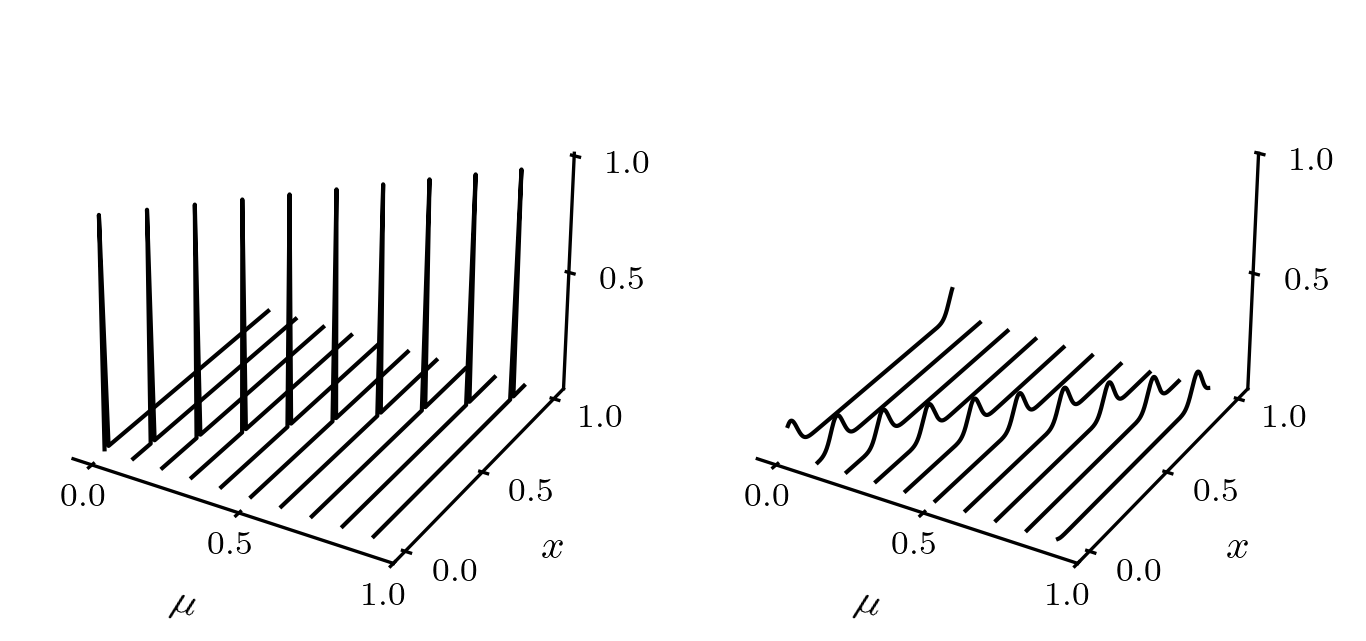

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


mean ROM: 0.098976
mean esROM: 0.079918 (19.2552%)
mean esROMs: 0.037220 (62.3953%)
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 250, 0.03461111, 4.75308642, 0.09897644, 0.07991837, 0.03721984, -62.3953
mean ROM: 0.098976
mean esROM: 0.079918 (19.2552%)
mean esROMs: 0.037220 (62.3953%)


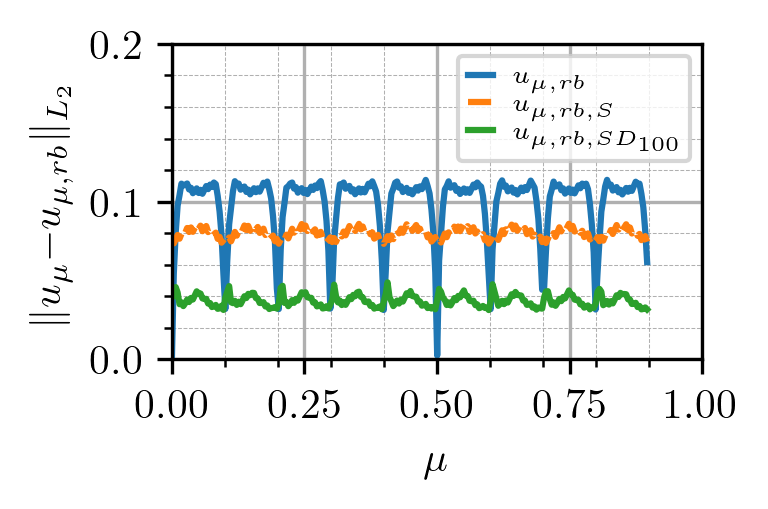

[0.] [0.1]


C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


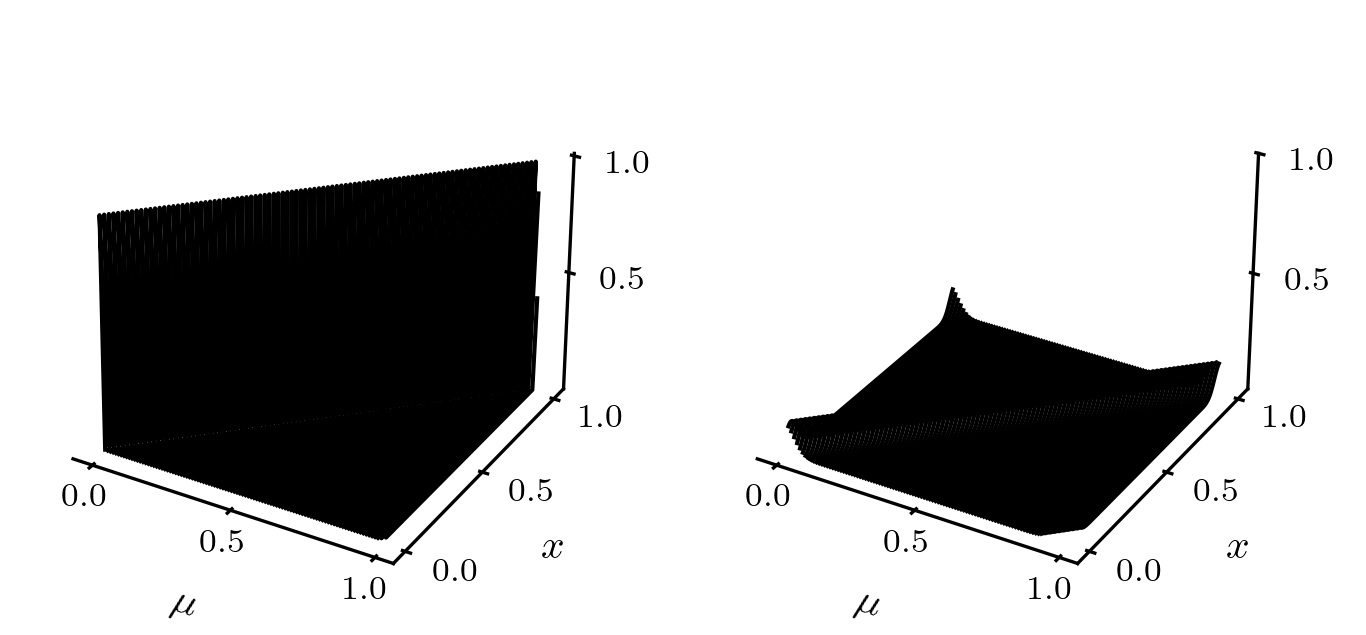

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


mean ROM: 0.039340
mean esROM: 0.075293 (-91.3901%)
mean esROMs: 0.035910 (8.7188%)
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 250, 0.03461111, 4.75308642, 0.03891406, 0.07489329, 0.03529289, -9.3055
mean ROM: 0.038914
mean esROM: 0.074893 (-91.3901%)
mean esROMs: 0.035293 (8.7188%)


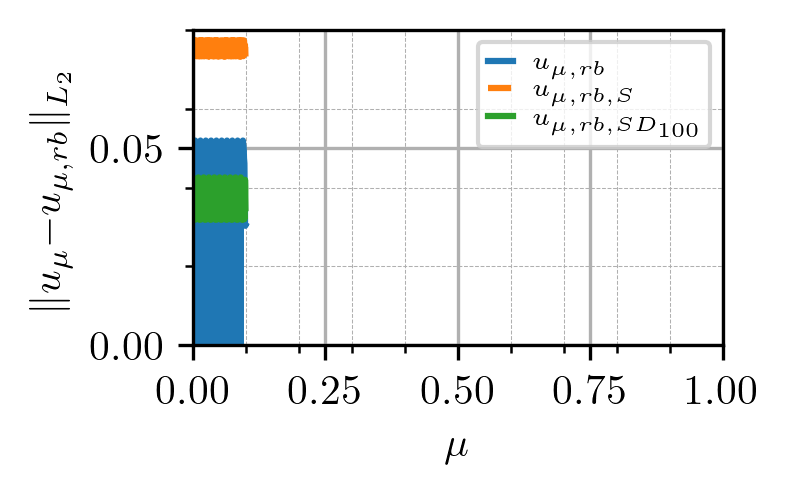

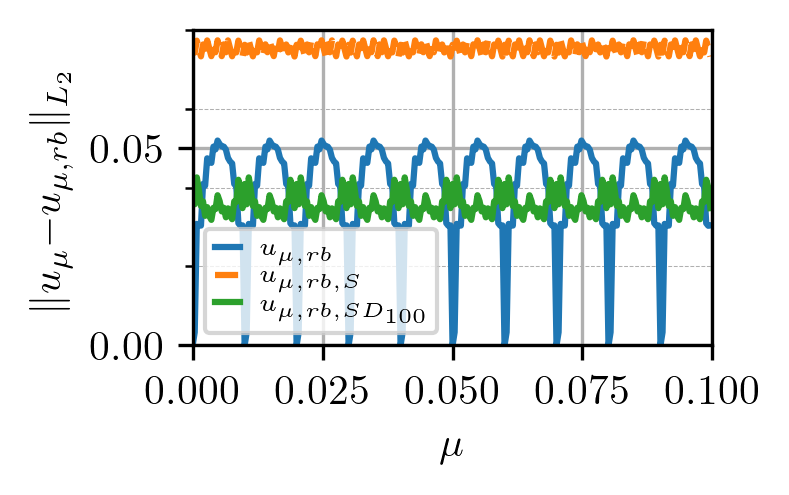

100
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00550000, 5.00000000, 0.03933999, 0.04182399, 0.05406001, 37.4175
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00850000, 5.00000000, 0.03933999, 0.04953213, 0.05439383, 38.2660
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00250000, 5.00000000, 0.03933999, 0.03576204, 0.04171594, 6.0395
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00550000, 8.33333333, 0.03933999, 0.04182399, 0.05502352, 39.8666
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00550000, 1.66666667, 0.03933999, 0.04182399, 0.04190925, 6.5309
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 25, 0.00250000, 8.33333333

C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


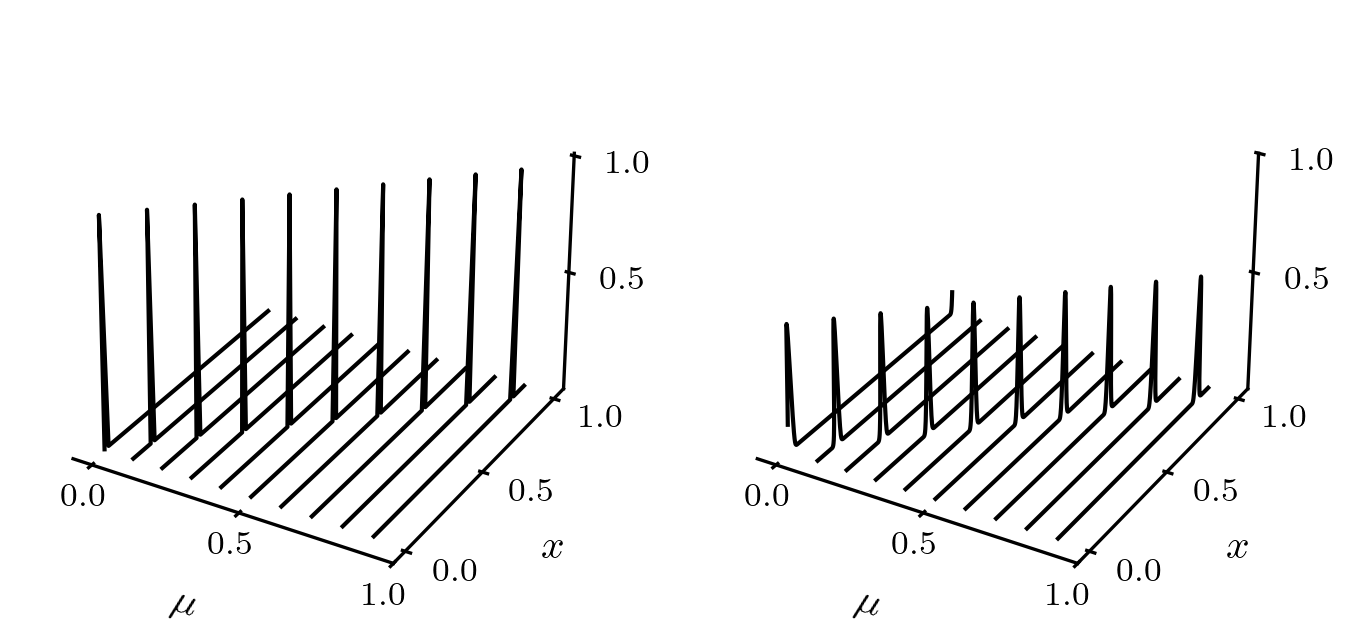

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


mean ROM: 0.098976
mean esROM: 0.087790 (11.3022%)
mean esROMs: 0.107379 (-8.4894%)
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 250, 0.00650000, 0.55555556, 0.09897644, 0.08778992, 0.10737890, 8.4894
mean ROM: 0.098976
mean esROM: 0.087790 (11.3022%)
mean esROMs: 0.107379 (-8.4894%)


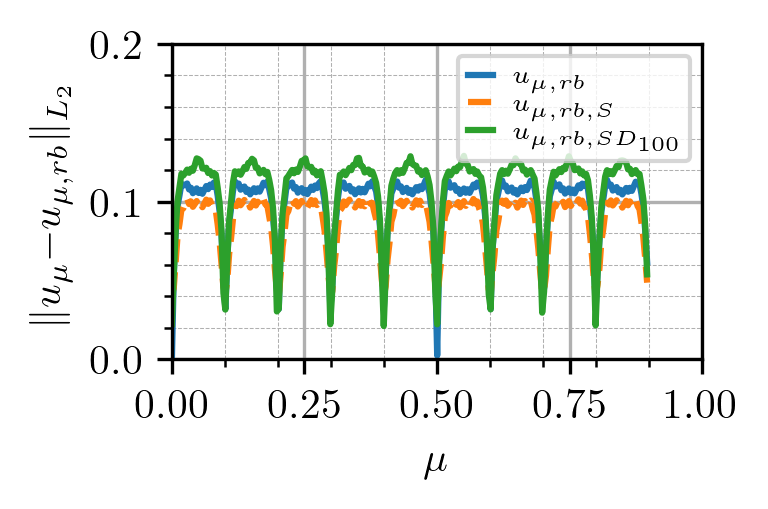

[0.] [0.1]


C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


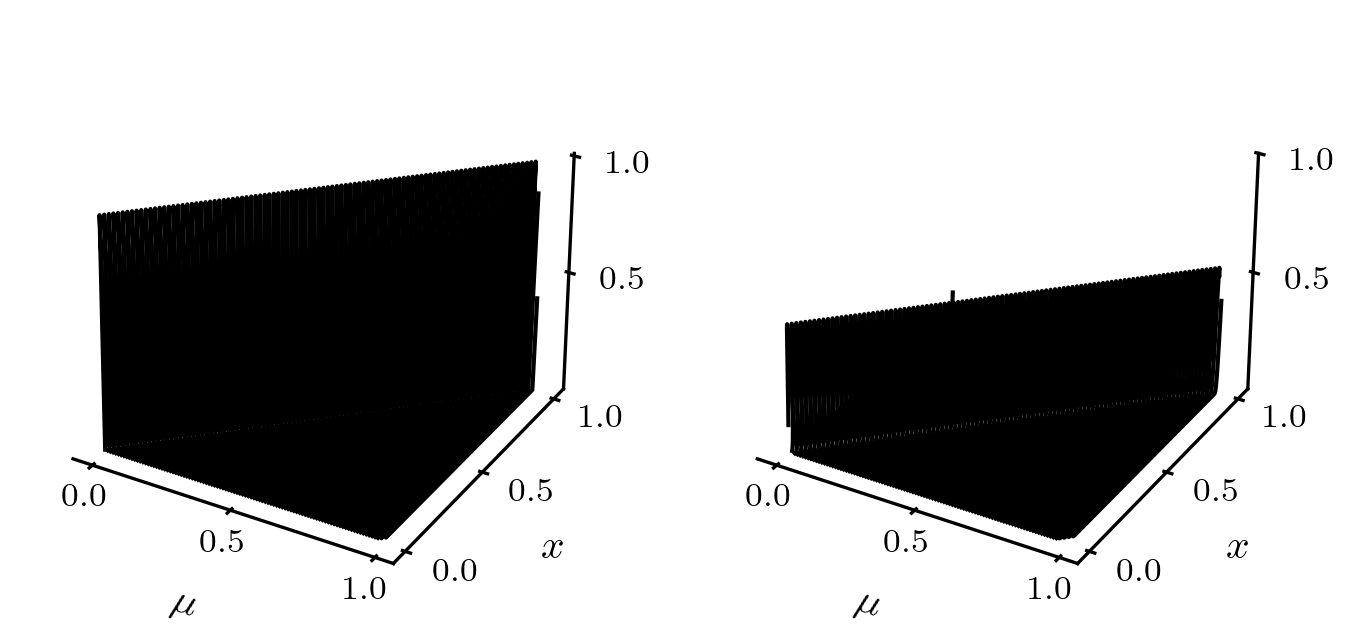

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


mean ROM: 0.039340
mean esROM: 0.044434 (-12.9481%)
mean esROMs: 0.025210 (35.9165%)
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 100, 250, 0.00650000, 0.55555556, 0.03891406, 0.04421328, 0.02507255, -35.5694
mean ROM: 0.038914
mean esROM: 0.044213 (-12.9481%)
mean esROMs: 0.025073 (35.9165%)


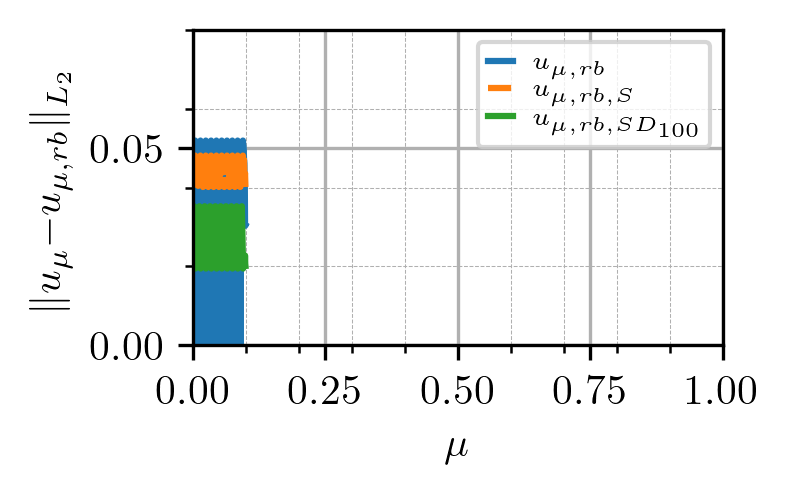

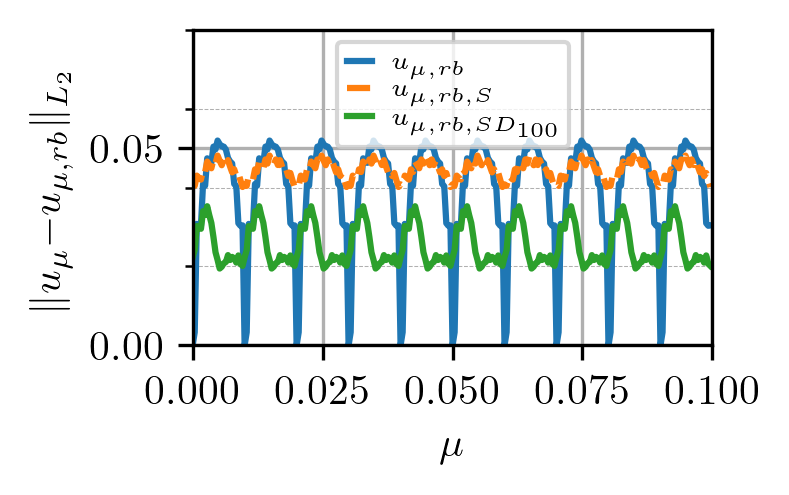

In [5]:
for rank in [10, 100]:
    n_train = rank
    print(rank)
    case["rank"] = rank
    case["n_train"] = n_train
    case["n_test"] = 25
    parameters = optimize_hyperparameters(case)
    case["n_test"] = 250
    # if rank == 10:
    #     parameters = np.array([0.03461111, 5.12345679])
    # elif rank == 100:
    #     parameters = np.array([0.00627778, 0.55555556])

    case["sigma"], case["c"] = parameters[0], parameters[1]
    #case["sigma"], case["c"] = 0.046817495544034825, 3.4777597632478527
    #case["sigma"], case["c"] = 0.046817495544034825, 3.4777597632478527
    for rank, ylim in zip([10, 100], (0.2, 0.08)):
        n_train = rank
        case["rank"] = rank
        case["n_train"] = n_train
        mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
        mu_test, X_test, X_test_s = make_data_rw(mu_train[1], mu_train[2], n_samples=case["n_test"], **case)
        print(mu_train[0], mu_train[min(len(mu_train)-1, 10)])
        mu_val, X_val, X_val_s = make_data_rw(mu_train[0], mu_train[min(len(mu_train)-1, 10)], n_samples=case["n_test"], **case)

        
        Fig3(x, mu_train, X_train, X_train_s)
    
        my_ROM = train_ROM_rw(mu_train, X_train)
        my_sROM = train_ROM_rw(mu_train, X_train_s)
    
        X_val_ROM = my_ROM.predict(mu_val).snapshots_matrix
        X_val_sROM, X_val_sROMs = get_predictions(my_sROM, mu_val, **case)

        # replace test with val
        mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
            X_val, X_val_ROM, X_val_sROM, X_val_sROMs
        )
    
        eROM = L2_error_rw(X_val_ROM, X_val)
        esROM = L2_error_rw(X_val_sROM, X_val)
        esROMs = L2_error_rw(X_val_sROMs, X_val)
        imp1 = 100 - np.mean(esROM) / np.mean(eROM) * 100
        imp2 = 100 - np.mean(esROMs) / np.mean(eROM) * 100
        print("mean ROM: {:.6f}".format(np.mean(eROM)))
        print("mean esROM: {:.6f} ({:.4f}%)".format(np.mean(esROM), imp1))
        print("mean esROMs: {:.6f} ({:.4f}%)".format(np.mean(esROMs), imp2))

        mean_ROM, mean_sROM, mean_sROMs = target_function(case)
        print("mean ROM: {:.6f}".format(mean_ROM))
        print("mean esROM: {:.6f} ({:.4f}%)".format(mean_sROM, imp1))
        print("mean esROMs: {:.6f} ({:.4f}%)".format(mean_sROMs, imp2))
    
        fig, ax = Fig6(mu_val, eROM, esROM, esROMs)
        ax.set_ylim(0, ylim)
        plt.show()

        if len(mu_train) > 10:
            fig, ax = Fig6(mu_val, eROM, esROM, esROMs)
            ax.set_xlim(mu_train[0], mu_train[10])
            ax.set_ylim(0, ylim)
            plt.show()
    
        #for (sigma, c) in zip((0.0468, 0.0471, 0.0106), (3.478, 0.9473, 1.1437)):


In [6]:
for rank in [10, 100]:
    n_train = rank
    print("\n", rank)
    case["rank"] = rank
    case["n_train"] = n_train
    for n_x in [500, 1000, 2500, 5000]:
        print("n_x=", n_x)
        x = np.linspace(0, 1, n_x, endpoint=False)
        case["n_x"] = n_x
        case["shape"] = x.shape
        case["x"] = x
        case["dx"] = x[1] - x[0]
        for ntst in [10, 20, 50, 100, 200, 500]:
            case["n_test"] = ntst
            mean_ROM, mean_sROM, mean_sROMs = target_function(case)


 10
n_x= 500
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 10, 0.00650000, 0.55555556, 0.09858731, 0.09134667, 0.10968599, 11.2577
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 20, 0.00650000, 0.55555556, 0.09935206, 0.08927353, 0.10928422, 9.9969
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 50, 0.00650000, 0.55555556, 0.10244205, 0.09147455, 0.11104360, 8.3965
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 100, 0.00650000, 0.55555556, 0.10062234, 0.08929084, 0.10932880, 8.6526
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 200, 0.00650000, 0.55555556, 0.09973263, 0.08822027, 0.10849406, 8.7849
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
250, 10, 500, 0.00650000, 0.555

In [7]:
asd

NameError: name 'asd' is not defined

In [ ]:
n_x = 1000
n_train = 50
n_test = 10
num_iter1 = 100
#num_iter2 = 250
# num_iter3 = 1000
#num_iter4 = 2500

In [ ]:
rank = n_train
dx = 1 / n_x
shape = (n_x,)
clip = True

In [ ]:
x = np.linspace(0, 1, n_x, endpoint=False)
mu_train = np.linspace([0.0], [1.0], n_train, endpoint=False)
mu_test = np.linspace(mu_train[1], mu_train[2], n_test, endpoint=False)

g = rectangular_pulse

X_train = snapshots(g, x, mu_train)
X_test = snapshots(g, x, mu_test)

In [ ]:
#sigma, c = optimize_hyperparameters(x, mu_train, mu_test, X_train, X_test, shape, num_iter2, clip, rank)
rank, sigma, c = 10, 0.046817495544034825, 3.4777597632478527  # -77.5, num_iter2=250, n_test=10
rank, sigma, c = 20, 0.04709477073255084, 0.9473123624789438  # -64.5, num_iter2=250, n_test=10
rank, sigma, c = 50, 0.010637015820358114, 1.1437423194705931  # -53.5667, num_iter2=250, n_test=10

In [ ]:
X_train_s = smoothen(X_train, sigma / dx, x.shape, truncate=12)
X_test_s = smoothen(X_test, sigma / dx, x.shape, truncate=12)

Fig3(x, mu_train, X_train, X_train_s)

In [ ]:
def Fig6(mu_val, eROM, esROM, esROMs):
    fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
    ax.plot(mu_val, eROM, "C0-", label=r"$u_{\mu, rb}$")
    ax.plot(mu_val, esROM, "C1--", label=r"$u_{\mu, rb, S}$")
    ax.plot(mu_val, esROMs, "C2-", label=r"$u_{\mu, rb, SD_{100}}$")
#    ax.plot(mu_val, esROMs2, "C3-", label="$u_{\mu, rb, SD_{1000}}$")
    plt.ylabel(r"$\|u_{\mu}{-u_{\mu, rb}}\|_{L_2}$")
    plt.xlabel(r"$\mu$")
    plt.legend()
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
    plt.grid(True, which="minor", linestyle="--", lw=0.25)
    plt.grid(True, which="major", linestyle="-")
    plt.xlim(0, 1)
    # plt.show()
    return fig, ax

In [ ]:
for rank, ylim in zip([10, 20, 50], (0.4, 0.3, 0.2)):
    for (sigma, c) in zip((0.0468, 0.0471, 0.0106), (3.478, 0.9473, 1.1437)):
        print(rank, sigma, c)
        mu_train = np.linspace([0.0], [1.0], rank, endpoint=False)
        X_train = snapshots(g, x, mu_train)
        X_train_s = smoothen(X_train, sigma / dx, x.shape, truncate=12)

        mu_val = x.copy()
        interpolatable = (mu_train[0] < mu_val) & (mu_val < mu_train[-1])
        mu_val = mu_val[interpolatable][:, None]
        X_val = snapshots(g, x, mu_val)
        X_val_s = smoothen(X_val, sigma / dx, x.shape, truncate=12)
        
        Fig3(x, mu_train, X_train, X_train_s)

        print("build ROM and predict")
        standard_rom = train_ROM(mu_train, X_train, rank=rank)
        smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
        X_test_ROM = standard_rom.predict(mu_test).snapshots_matrix.T
        X_val_ROM = standard_rom.predict(mu_val).snapshots_matrix.T
        X_test_sROM = smooth_rom.predict(mu_test).snapshots_matrix.T
        X_val_sROM = smooth_rom.predict(mu_val).snapshots_matrix.T


        print("model performance validation")
        X_val_sROMs = post_process(
            x, X_val_sROM, sigma, c, mu_val, mu_train, num_iter1, shape, clip=clip, progress=False
        )
#        X_val_sROMs2 = post_process(
#            x, X_val_sROM, sigma, c, mu_val, mu_train, num_iter2, shape, clip=clip, progress=True
#        )
        eROM = L2_error(X_val_ROM, X_val)
        esROM = L2_error(X_val_sROM, X_val)
        esROMs = L2_error(X_val_sROMs, X_val)
#        esROMs2 = L2_error(X_val_sROMs2, X_val)
        imp1 = 100 - np.mean(esROMs) / np.mean(eROM) * 100
#        imp2 = 100 - np.mean(esROMs2) / np.mean(eROM) * 100
        print("average improvement ({:.0f} iterations): {:.2f}".format(num_iter1, imp1))
#        print("average improvement ({:.0f} iterations): {:.2f}".format(num_iter2, imp2))

        fig, ax = Fig6(mu_val, eROM, esROM, esROMs)
        ax.set_ylim(0, ylim)